# Decision Tree

**Dataset:** Heart Disease (`cleaned_merged_heart_dataset.csv`)
**Target variable:** `target` (binary heart disease label)

This notebook follows the standard methodology:

1. Dataset Loading & Preview
2. Preprocessing Pipeline
3. Hyperparameter Tuning Log
4. Final Model Selection Leaderboard
5. Best Model Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')


## 1. Dataset Loading & Preview

Load the dataset and inspect the first few rows (mirroring the dataset preview at the top of each Excel sheet).


In [2]:
df = pd.read_csv('/content/cleaned_merged_heart_dataset.csv')
print(f"Dataset shape: {df.shape}")
display(df.head())

print("\nColumn information:")
df.info()


Dataset shape: (1888, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1888 entries, 0 to 1887
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1888 non-null   int64  
 1   sex       1888 non-null   int64  
 2   cp        1888 non-null   int64  
 3   trestbps  1888 non-null   int64  
 4   chol      1888 non-null   int64  
 5   fbs       1888 non-null   int64  
 6   restecg   1888 non-null   int64  
 7   thalachh  1888 non-null   int64  
 8   exang     1888 non-null   int64  
 9   oldpeak   1888 non-null   float64
 10  slope     1888 non-null   int64  
 11  ca        1888 non-null   int64  
 12  thal      1888 non-null   int64  
 13  target    1888 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 206.6 KB


## 2. Preprocessing Pipeline

A structured preprocessing pipeline, organised the same way as the Titanic sheet in the bake-off template.

### 1. Handling Missing Values (Imputation)
- **Numeric columns:** Use the **median** to avoid the influence of outliers.
- **Categorical columns:** Use the **mode** (most frequent value).

### 2. Feature Engineering / Selection
- Drop redundant text columns (`sex_text`, `thal_text`) since `sex` and `thal` are already numerical.
- Separate features (`X`) from target (`y` = `target`, the heart disease label).

### 3. Categorical Encoding
- `sex` and `thal` are already label-encoded as numeric → no further encoding required.
- Any leftover non-numeric columns are one-hot encoded as a safety net.

### 4. Feature Scaling — *not required for trees*
Decision trees are **scale-invariant** because they split on threshold comparisons (e.g. `age <= 54.5`) rather than distances. Skipping scaling keeps the tree's split values directly interpretable in the original units.


In [3]:
# 1. Handling Missing Values
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

for c in num_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].mode().iloc[0])

# 2. Feature Engineering / Selection — target is 'target' (heart disease label)
X = df.drop('target', axis=1)
y = df['target']

for col in ['sex_text', 'thal_text']:
    if col in X.columns:
        X = X.drop(col, axis=1)

# 3. Categorical Encoding — one-hot any residual non-numeric columns (safety net)
X = pd.get_dummies(X, drop_first=True)

# 4. No scaling — decision trees are scale-invariant.

print("Preprocessing complete.")
print(f"Feature matrix X: {X.shape}")
print(f"Target vector y: {y.shape}")


Preprocessing complete.
Feature matrix X: (1888, 13)
Target vector y: (1888,)


### Train / Test Split

A 70/30 stratified split keeps class balance consistent across folds.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test:  {X_test.shape}")
print(f"\ny_train class balance:\n{y_train.value_counts().to_string()}")


Shape of X_train: (1321, 13)
Shape of X_test:  (567, 13)

y_train class balance:
target
1    684
0    637


## 3. Hyperparameter Tuning Log — Decision Tree

Each row below is a single experiment in the bake-off. Columns mirror the **Hyperparameter Tuning Log** in the Excel template:

| Exp ID | Criterion | Max Depth | Min Samples Leaf | Validation Accuracy | F1-Score | Status | Insights |

- **Criterion** — `gini` (Gini impurity) vs `entropy` (information gain). Both measure node purity; in practice they produce very similar trees.
- **Max Depth** — the most important regularizer. `None` = grow until pure (high variance, overfits); small values force shallow, generalisable trees.
- **Min Samples Leaf** — minimum samples required at a leaf node. Larger values smooth predictions and prevent splits that fit individual training points.
- **Status** flags how each trial compares to the baseline (`DT_01`): *Baseline*, *Better*, *Worse*, or *Overfitting?*.


In [5]:
experiments = [
    {'Exp ID': 'DT_01', 'Criterion': 'gini',    'Max Depth': None, 'Min Samples Leaf': 1},
    {'Exp ID': 'DT_02', 'Criterion': 'gini',    'Max Depth': 3,    'Min Samples Leaf': 2},
    {'Exp ID': 'DT_03', 'Criterion': 'gini',    'Max Depth': 5,    'Min Samples Leaf': 2},
    {'Exp ID': 'DT_04', 'Criterion': 'entropy', 'Max Depth': 5,    'Min Samples Leaf': 4},
    {'Exp ID': 'DT_05', 'Criterion': 'entropy', 'Max Depth': 10,   'Min Samples Leaf': 4},
]

results = []
trained_models = {}

for exp in experiments:
    model = DecisionTreeClassifier(
        criterion=exp['Criterion'],
        max_depth=exp['Max Depth'],
        min_samples_leaf=exp['Min Samples Leaf'],
        random_state=42,
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)

    results.append({
        'Exp ID': exp['Exp ID'],
        'Criterion': exp['Criterion'],
        'Max Depth': exp['Max Depth'],
        'Min Samples Leaf': exp['Min Samples Leaf'],
        'Validation Accuracy': round(acc, 4),
        'F1-Score': round(f1, 4),
    })
    trained_models[exp['Exp ID']] = model

results_df = pd.DataFrame(results)

# --- Status column (Baseline / Better / Worse / Overfitting?) ---
baseline_acc = results_df.iloc[0]['Validation Accuracy']

def status_for(row, baseline):
    acc = row['Validation Accuracy']
    if row['Exp ID'] == 'DT_01':
        return 'Baseline'
    # Unrestricted / very deep tree with mediocre accuracy → likely overfitting
    if (row['Max Depth'] is None or row['Max Depth'] >= 10) and acc < baseline + 0.01:
        return 'Overfitting?'
    if acc > baseline:
        return 'Better'
    if acc < baseline:
        return 'Worse'
    return 'Same'

results_df['Status'] = results_df.apply(lambda r: status_for(r, baseline_acc), axis=1)

# --- Insights column ---
insights_map = {
    'DT_01': 'Fully grown tree (no depth limit) — high variance, classic overfit baseline.',
    'DT_02': 'Shallow tree (depth=3) — strong regularization, may underfit.',
    'DT_03': 'Moderate depth=5 with gini — balanced bias / variance.',
    'DT_04': 'Entropy + min_leaf=4 — slightly smoother splits than gini.',
    'DT_05': 'Deeper tree (depth=10) regularised via min_samples_leaf=4.',
}
results_df['Insights'] = results_df['Exp ID'].map(insights_map)

# Display with 'None' as string for readability
display(results_df.fillna('None'))


,Exp ID,Criterion,Max Depth,Min Samples Leaf,Validation Accuracy,F1-Score,Status,Insights
0,DT_01,gini,None,1,0.9541,0.9561,Baseline,Fully grown tree (no depth limit) — high varia...
1,DT_02,gini,3.0,2,0.8272,0.8377,Worse,Shallow tree (depth=3) — strong regularization...
2,DT_03,gini,5.0,2,0.8730,0.8784,Worse,Moderate depth=5 with gini — balanced bias / v...
3,DT_04,entropy,5.0,4,0.8660,0.8707,Worse,Entropy + min_leaf=4 — slightly smoother split...
4,DT_05,entropy,10.0,4,0.9118,0.9135,Overfitting?,Deeper tree (depth=10) regularised via min_sam...


### Diagnostic: Max Depth vs Validation Accuracy

A complementary view — sweep `max_depth` to confirm where the bias / variance sweet spot sits. The plot below holds `criterion='gini'` and `min_samples_leaf=2` fixed and varies depth from 1 to 20.


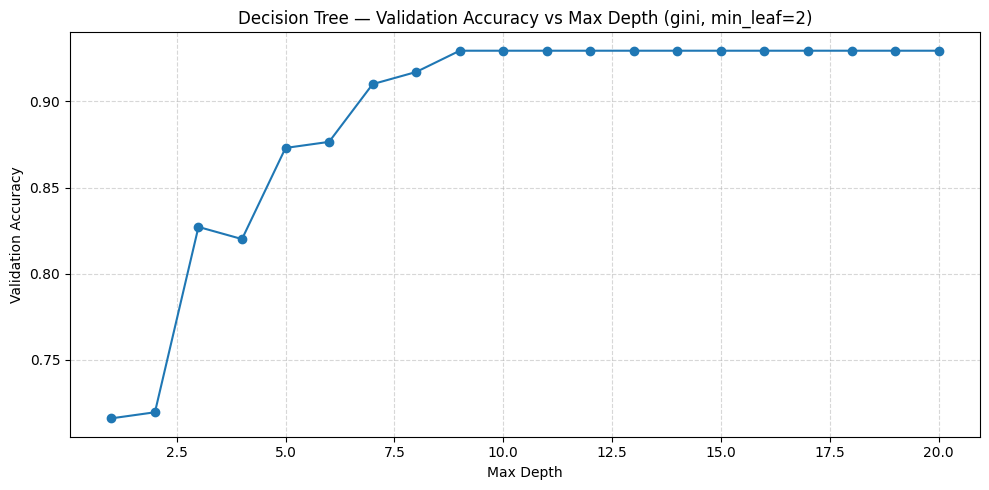

Best depth from sweep: 9 (acc = 0.9295)


In [6]:
depth_range = range(1, 21)
depth_scores = []
for d in depth_range:
    m = DecisionTreeClassifier(criterion='gini', max_depth=d, min_samples_leaf=2, random_state=42)
    m.fit(X_train, y_train)
    depth_scores.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(list(depth_range), depth_scores, marker='o')
plt.title('Decision Tree — Validation Accuracy vs Max Depth (gini, min_leaf=2)')
plt.xlabel('Max Depth')
plt.ylabel('Validation Accuracy')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_depth_sweep = list(depth_range)[int(np.argmax(depth_scores))]
print(f"Best depth from sweep: {best_depth_sweep} (acc = {max(depth_scores):.4f})")


## 4. Final Model Selection Leaderboard

Sorted by **Validation Accuracy** (descending), with the same column layout as the Excel leaderboard:
`Rank | Model | Best Hyperparameters | Accuracy | F1-Score | Note`.


In [12]:
ranked = results_df.sort_values('Validation Accuracy', ascending=False).reset_index(drop=True)

def note_for(rank, total):
    if rank == 0:
        return 'Top Performer'
    if rank == 1:
        return 'Strong Runner-up'
    if rank == total - 1:
        return 'Weak Baseline'
    return 'Acceptable'

leaderboard = pd.DataFrame({
    'Rank': range(1, len(ranked) + 1),
    'Model': ['Decision Tree'] * len(ranked),
    'Best Hyperparameters': ranked.apply(
        lambda r: f"criterion={r['Criterion']}, depth={r['Max Depth']}, min_leaf={r['Min Samples Leaf']}", axis=1
    ),
    'Accuracy': ranked['Validation Accuracy'],
    'F1-Score': ranked['F1-Score'],
    'Note': [note_for(i, len(ranked)) for i in range(len(ranked))],
})

display(leaderboard)

best_exp_id = ranked.iloc[0]['Exp ID']
best_model  = trained_models[best_exp_id]
print(f"\nBest experiment: {best_exp_id}")
print(f"Hyperparameters: {leaderboard.iloc[0]['Best Hyperparameters']}")
print(f"Accuracy:        {leaderboard.iloc[0]['Accuracy']:.4f}")
print(f"F1-Score:        {leaderboard.iloc[0]['F1-Score']:.4f}")


,Rank,Model,Best Hyperparameters,Accuracy,F1-Score,Note
0,1,Decision Tree,"criterion=gini, depth=nan, min_leaf=1",0.9541,0.9561,Top Performer
1,2,Decision Tree,"criterion=entropy, depth=10.0, min_leaf=4",0.9118,0.9135,Strong Runner-up
2,3,Decision Tree,"criterion=gini, depth=5.0, min_leaf=2",0.8730,0.8784,Acceptable
3,4,Decision Tree,"criterion=entropy, depth=5.0, min_leaf=4",0.8660,0.8707,Acceptable
4,5,Decision Tree,"criterion=gini, depth=3.0, min_leaf=2",0.8272,0.8377,Weak Baseline



Best experiment: DT_01
Hyperparameters: criterion=gini, depth=nan, min_leaf=1
Accuracy:        0.9541
F1-Score:        0.9561


## 5. Best Model Analysis

Detailed evaluation of the top-ranked experiment from the leaderboard.


In [8]:
y_pred_best = best_model.predict(X_test)

print(f"Best Model: {best_exp_id}")
print(f"Accuracy:   {accuracy_score(y_test, y_pred_best):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_best))


Best Model: DT_01
Accuracy:   0.9541

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       274
           1       0.95      0.97      0.96       293

    accuracy                           0.95       567
   macro avg       0.95      0.95      0.95       567
weighted avg       0.95      0.95      0.95       567



### Confusion Matrix

- **True Negatives (Top-Left):** Correctly predicted negative cases.
- **False Positives (Top-Right):** Incorrectly predicted positive cases (Type I error).
- **False Negatives (Bottom-Left):** Incorrectly predicted negative cases (Type II error).
- **True Positives (Bottom-Right):** Correctly predicted positive cases.


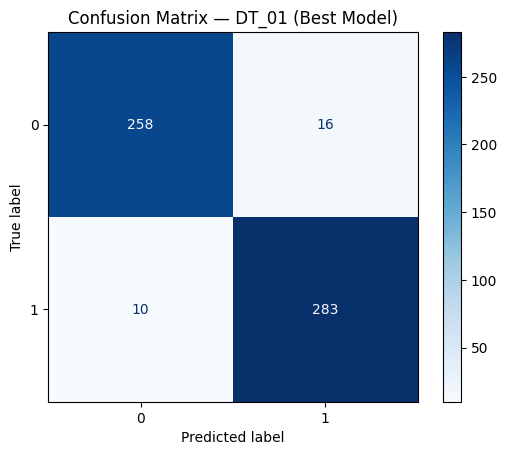

In [9]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix — {best_exp_id} (Best Model)')
plt.show()


### Feature Importance (Information Gain)

For decision trees, feature importance is the **total reduction in impurity** (Gini or entropy) contributed by splits on each feature, weighted by the number of samples they route. Larger values imply the feature drove more decisive splits near the top of the tree.


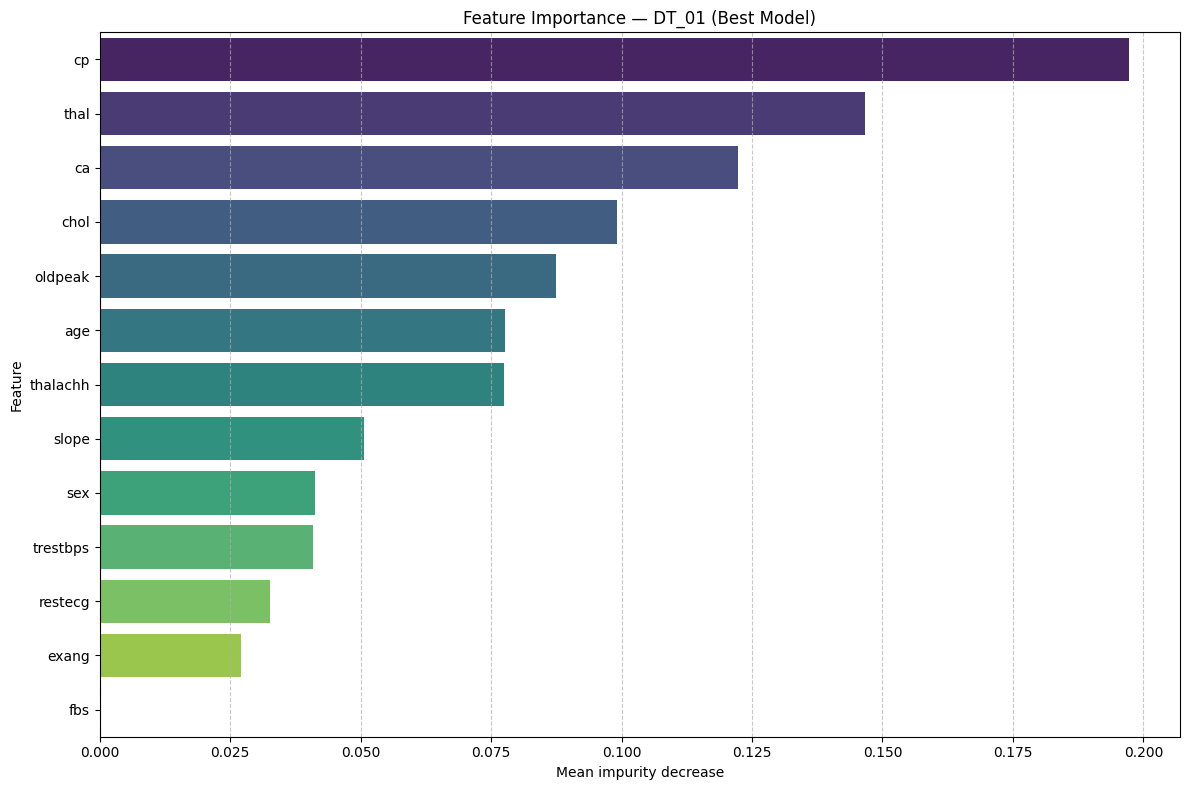

In [10]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_,
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
    x='importance', y='feature', data=feature_importance,
    palette='viridis', hue='feature', legend=False,
)
plt.title(f'Feature Importance — {best_exp_id} (Best Model)')
plt.xlabel('Mean impurity decrease')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Decision Tree Visualization

A direct visualization of the trained best-model tree. Each node shows:

- **`samples`** — number of training samples reaching that node.
- **`value`** — class counts at that node, e.g. `[count_class_0, count_class_1]`.
- **`class`** — majority class at that node.

For deep trees the diagram can be large; consider zooming in for details.


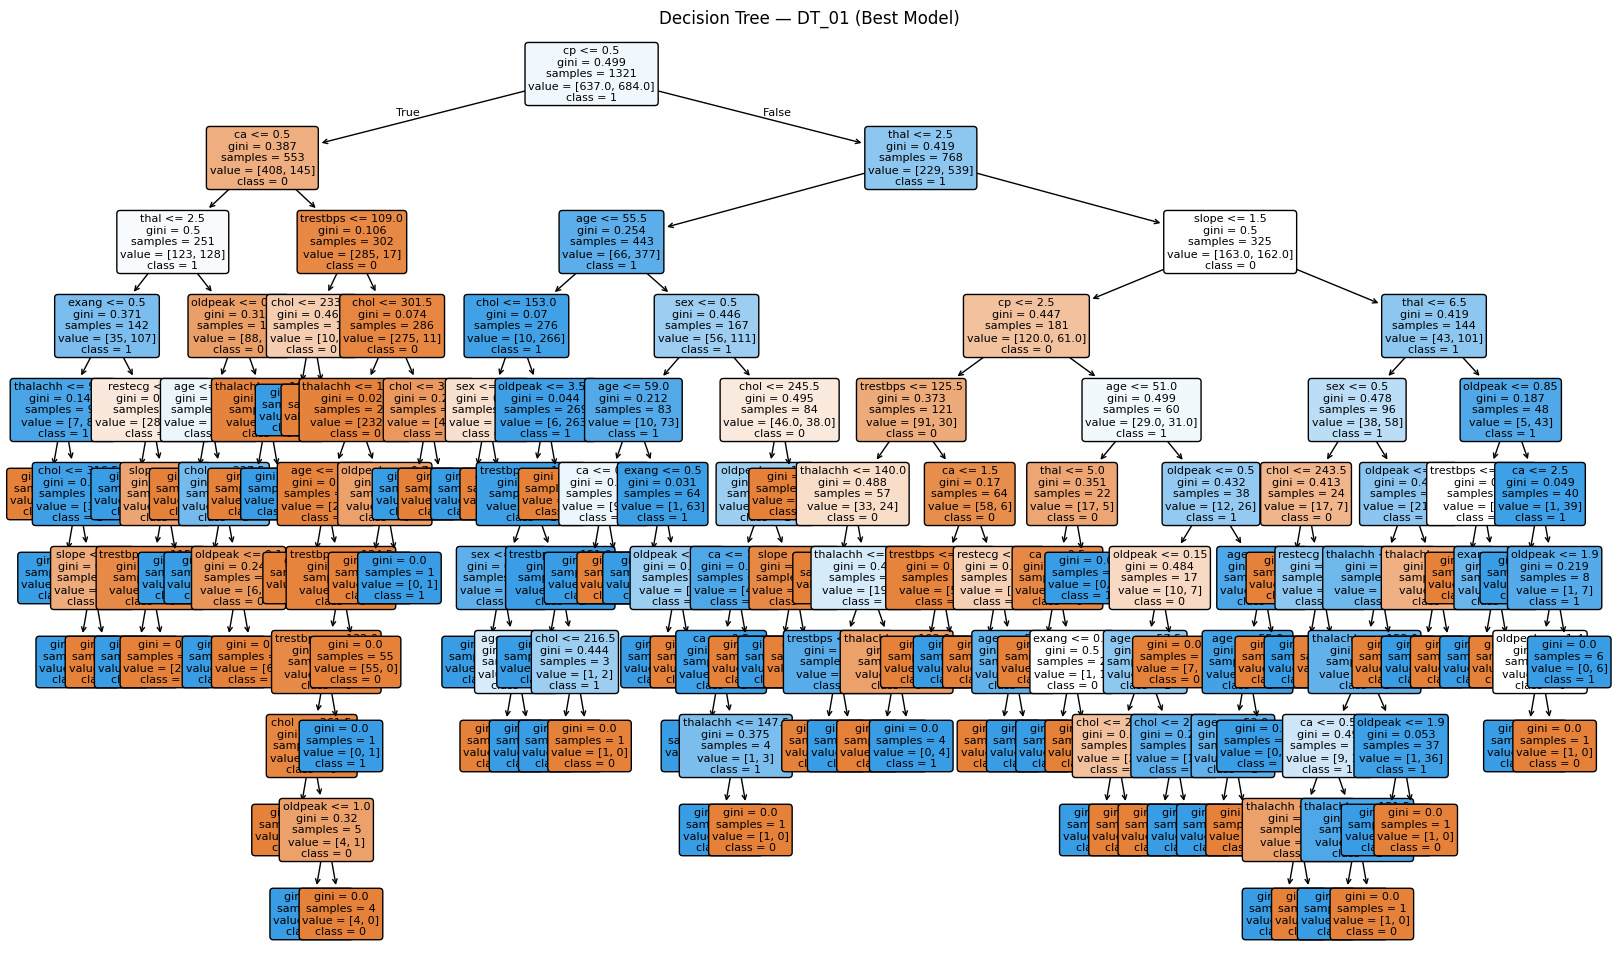

In [11]:
plt.figure(figsize=(20, 12))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=[str(c) for c in best_model.classes_],
    filled=True,
    rounded=True,
    proportion=False,
    fontsize=8,
)
plt.title(f'Decision Tree — {best_exp_id} (Best Model)')
plt.show()


## Conclusion

The Decision Tree bake-off ran **5 experiments** (`DT_01`–`DT_05`) sweeping `criterion`, `max_depth`, and `min_samples_leaf`. The hyperparameter tuning log captures each trial's validation accuracy alongside a status flag and qualitative insight, exactly as in the Excel template. The depth-sweep diagnostic gives a finer-grained view of where the bias / variance sweet spot sits.

The **Final Model Selection Leaderboard** ranks the experiments end-to-end and identifies the top performer for downstream analysis. Confusion matrix, feature importance, and the tree visualization are then produced **only for the winning model**, keeping the analysis tightly coupled to the leaderboard's verdict.

This format scales naturally — adding a new model family (Logistic Regression, KNN, Random Forest, SVM, Gradient Boosting) is a matter of appending another tuning log section and merging the results into the same leaderboard, mirroring the four-model bake-off shown on the Titanic sheet.
